![Clase aprendizaje no supervisado](https://raw.githubusercontent.com/MECA4605-Aprendizaje-no-supervisado/taller_2/main/figs/taller-meca-aprendizaje%20no%20supervisado_banner%201169%20x%20200%20px%20-05.png)

# Caso-taller: Reconocimiento facial con K-medias y K-medoides

En este caso-taller vamos a aplicar K-medias y K-medoides para agrupar rostros de indiviudos. Utilizaremos la base de datos conocida como Caras Olivetti. Esta base contiene diez imágenes diferentes de  40 personas distintas. Para algunas personas, las imágenes se tomaron en diferentes momentos, variando la iluminación, las expresiones faciales (ojos abiertos/cerrados, sonriendo/sin sonreír) y los detalles faciales (gafas/sin gafas). Todas las imágenes fueron tomadas contra un fondo homogéneo oscuro con los sujetos en una posición frontal erguida (con tolerancia a algún movimiento lateral). Esta base viene incluida dentro de la libraría `scikit-learn` y fueron provistas por T&T Laboratories Cambridge para que la comunidad académica la utilice para la evaluación de modelos predictivos.

## Instrucciones generales

1. Para desarrollar el *cuaderno* primero debe descargarlo.

2. Para responder cada inciso deberá utilizar el espacio debidamente especificado.

3. La actividad será calificada sólo si sube el *cuaderno* de jupyter notebook con extensión `.ipynb` en la actividad designada como "entrega calificada por el personal".

4. El archivo entregado debe poder ser ejecutado localmente por el tutor. Sea cuidadoso con la especificación de la ubicación de los archivos de soporte, guarde la carpeta de datos en el mismo `path` de su cuaderno, por ejemplo: `data`.

## Desarrollo


### 1.Carga de datos

Los datos pueden ser bajados directamente utilizando la librería `scikit-learn`,  la función que le permite hacer esto es `fetch_olivetti_faces`.

In [1]:
#Configuración inicial del sistema
import sys
import sklearn
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_olivetti_faces

olivetti = fetch_olivetti_faces()

downloading Olivetti faces from https://ndownloader.figshare.com/files/5976027 to /root/scikit_learn_data


En primer lugar, se realiza la configuración inicial del entorno de trabajo mediante la importación de las principales librerías para el manejo de datos y visualización. Posteriormente, se cargó la base de datos y se asignó a una variable, lo que permite acceder a su contenido de manera organizada y reutilizarla fácilmente en los análisis y transformaciones posteriores.

### 2.  Análisis preliminar

#### 2.1. Describa los contenidos de la base de datos, tenga en cuenta que debe detallar los elementos, la dimensión de la base, y la dimensión de las imágenes. Genere una figura con una imagen de cada uno de los individuos

In [2]:
#Dimensiones de las imagenes
print("Dimensiones de los datos:", olivetti.data.shape)
print("Dimensiones de las imágenes:", olivetti.images.shape)
print("Dimensiones de los nombres:", olivetti.target.shape)
print("Descripción de la base:", olivetti.DESCR)

#Rango de pixeles
print("Rango de pixeles:", olivetti.data.min(), "-", olivetti.data.max())

Dimensiones de los datos: (400, 4096)
Dimensiones de las imágenes: (400, 64, 64)
Dimensiones de los nombres: (400,)
Descripción de la base: .. _olivetti_faces_dataset:

The Olivetti faces dataset
--------------------------

`This dataset contains a set of face images`_ taken between April 1992 and
April 1994 at AT&T Laboratories Cambridge. The
:func:`sklearn.datasets.fetch_olivetti_faces` function is the data
fetching / caching function that downloads the data
archive from AT&T.

.. _This dataset contains a set of face images: https://cam-orl.co.uk/facedatabase.html

As described on the original website:

    There are ten different images of each of 40 distinct subjects. For some
    subjects, the images were taken at different times, varying the lighting,
    facial expressions (open / closed eyes, smiling / not smiling) and facial
    details (glasses / no glasses). All the images were taken against a dark
    homogeneous background with the subjects in an upright, frontal position


En primer lugar, el componente *data* corresponde a una matriz donde cada fila representa una imagen en formato vector expresado en el número de sus píxeles. Por su parte, *images* almacena las imágenes en su formato bidimensional original, conservando su estructura visual. El elemento *target* es un vector que asigna a cada imagen una etiqueta numérica que identifica al individuo correspondiente. Finalmente, *DESCR* proporciona una descripción general del conjunto de datos. Esta organización permite trabajar tanto con la representación numérica como visual de las imágenes.

La base de datos contiene 400 imágenes en escala de grises correspondientes a 40 individuos distintos, con 10 imágenes por persona. Cada imagen tiene una dimensión de 64x64 píxeles, lo que equivale a 4096 variables cuando se representa en forma vectorizada.

#### 2.2. Genere una figura con una imagen de cada uno de los individuos

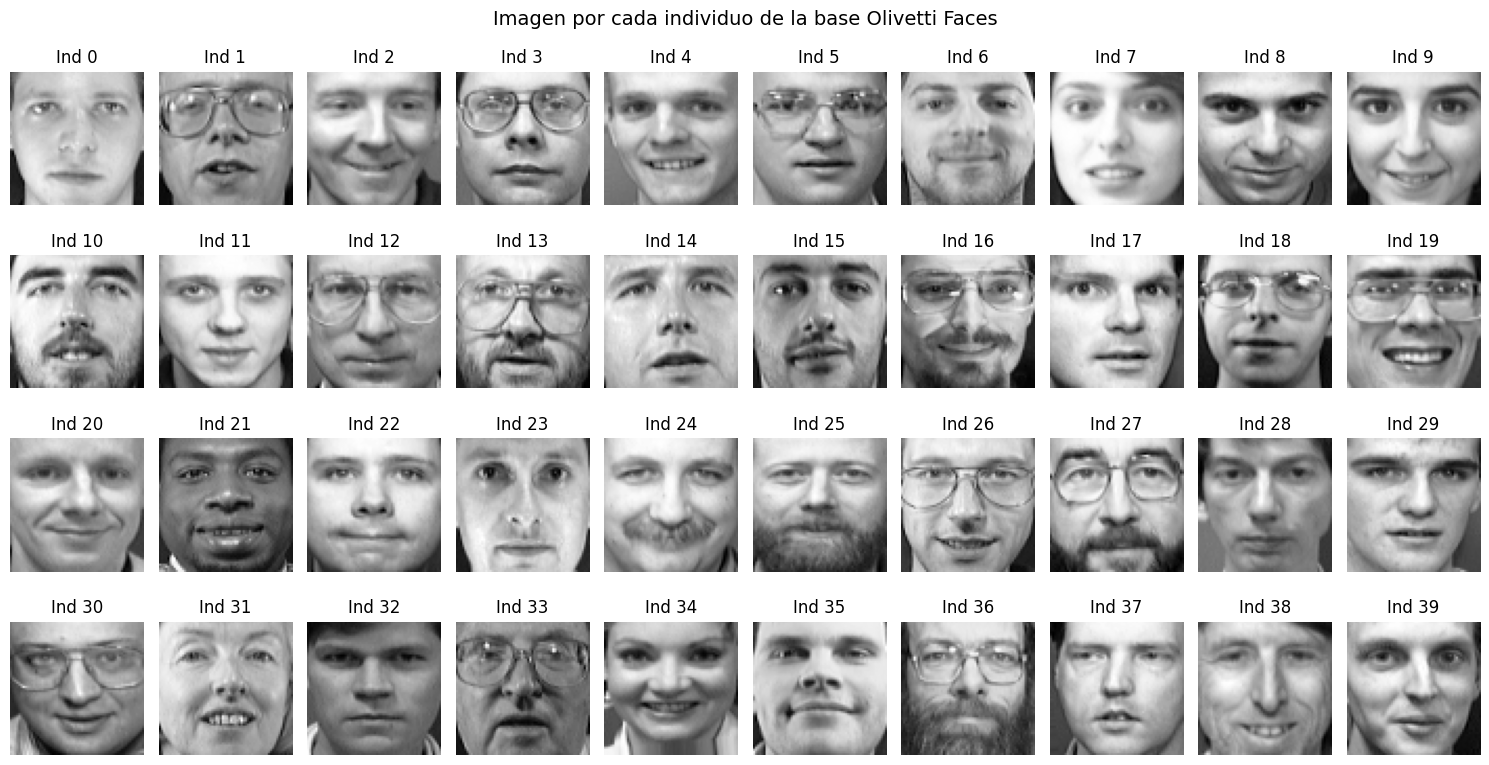

In [3]:
# Identificar los individuos únicos
individuos = np.unique(olivetti.target)

# Crear una figura con 4 filas y 10 columnas
fig, axes = plt.subplots(4, 10, figsize=(15, 8))
axes = axes.ravel()

# Recorrer cada individuo
for i, individuo in enumerate(individuos):
    # Buscar la primera imagen asociada a ese individuo
    idx = np.where(olivetti.target == individuo)[0][0]

    # Mostrar la imagen
    axes[i].imshow(olivetti.images[idx], cmap='gray')
    axes[i].set_title(f'Ind {individuo}')
    axes[i].axis('off')

plt.suptitle('Imagen por cada individuo de la base Olivetti Faces', fontsize=14)
plt.tight_layout()
plt.show()

Para visualizar la composición de la base de datos, se seleccionó una imagen representativa de cada individuo a partir de las etiquetas contenidas en *target*. Posteriormente, estas imágenes se organizaron en una cuadrícula, lo que permite observar de forma general los 40 rostros incluidos en la base de datos y verificar visualmente la diversidad de individuos presentes.

A partir de la visualización se evidencia que, aunque cada individuo es distinto, existen variaciones importantes en iluminación, expresión facial y orientación, lo cual puede dificultar los procesos de agrupamiento no supervisado.

#### 2.3. Transforme las imágenes en un data frame donde cada columna contiene los valores estandarizados del nivel de gris en la imagen y una columna con la etiqueta de cada imagen.

In [4]:
from sklearn.preprocessing import StandardScaler

# 1. Tomar la matriz de datos
X = olivetti.data

# 2. Estandarizar los valores de los píxeles
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 3. Convertir a DataFrame
olivetti_df = pd.DataFrame(X_scaled)

# 4. Agregar la columna de etiquetas
olivetti_df['target'] = olivetti.target

# Ver resultado
print(olivetti_df.shape)
olivetti_df.head()

(400, 4097)


,0,1,2,3,4,5,6,7,8,9,...,4087,4088,4089,4090,4091,4092,4093,4094,4095,target
0,-0.499903,-0.351181,-0.302961,-0.395361,-0.137608,0.104953,0.213296,0.194895,0.171393,0.065267,...,1.663787,1.598077,1.621725,0.726428,-1.092090,-0.959562,-0.898275,-0.831520,-0.850457,0
1,0.301499,0.194640,0.185686,0.203914,0.213404,0.290404,0.361849,0.355027,0.311534,0.180529,...,-1.157252,-1.249632,-1.096954,-1.007794,-0.982782,-0.938375,-0.898275,-0.876585,-0.873362,0
2,-0.454109,-0.176519,0.079458,0.054095,0.169528,0.383129,0.361849,0.248272,0.255478,0.151713,...,-1.293754,-0.999033,-1.162729,-1.141196,-1.004644,-0.980749,-0.964354,-0.899118,-0.873362,0
3,-1.118128,-1.268161,-1.450221,-1.679522,-1.936544,-2.236356,-2.262576,-1.566562,-1.230019,-1.116164,...,1.481785,1.620859,1.753274,2.082678,2.143408,2.197309,2.295495,2.390682,2.379127,0
4,0.553368,0.587631,0.546860,0.546357,0.498601,0.568579,0.436125,0.435093,0.395618,0.382236,...,-1.134501,-1.021815,-0.965405,-0.874393,-0.851614,-0.811252,-0.766119,-0.763921,-0.758838,0


Con el objetivo de facilitar el análisis de datos, las imágenes fueron transformadas en un DataFrame, donde cada fila representa una imagen y cada columna corresponde a un píxel. Asimismo, los valores de intensidad de los píxeles fueron estandarizados para que cada variable tuviera media cero y desviación estándar uno. Cabe resaltar que la estandarización se realiza con el fin de evitar que algunos píxeles dominen la medida de distancia utilizada en los algoritmos de clustering, garantizando que todas las variables tengan igual peso.

Finalmente, se añadió una columna adicional que contiene la etiqueta de cada imagen, lo que permite identificar el individuo correspondiente y facilita su uso en análisis posteriores.

### 3. Clasificando de forma no supervisada

En esta sección trataremos de clasificar las imágenes de los individuos de forma no supervisada. Para ello utilizaremos los algoritmos de k-medias y k-medoides. Dado que sabemos que el dataset consta de 40 personas diferentes, utilizaremos esta información para pedirle a los algoritmos encuentren k=40 clusters y examinaremos su precisión .


#### 3.1. Implemente k-medias sobre los datos estandarizados en el punto anterior. Al implementar utilice  `random_state=123` y `n_init=10`. (Esto puede tomar mucho tiempo y requerir mucho RAM, puede aprovechar los recursos de [Google Colab](https://colab.research.google.com/))

In [5]:
from sklearn.cluster import KMeans

# Separar variables explicativas y etiquetas
X = olivetti_df.drop(columns='target')
y = olivetti_df['target']

# Implementar K-means
kmeans = KMeans(n_clusters=40, random_state=123, n_init=10)
kmeans.fit(X)

# Etiquetas asignadas por el algoritmo
clusters_kmeans = kmeans.labels_

En esta sección se implementó el algoritmo de K-means sobre los datos estandarizados usando como fuente los valores de los píxeles y excluyendo la etiqueta de cada imagen. Dado que la base contiene 40 individuos, se fijó el número de clusters en 40 con el fin de comparar el agrupamiento obtenido con la clasificación real. Asimismo, se usó random_state=123 para garantizar la reproducibilidad de los resultados y n_init=10 para la estabilidad del algoritmo con varias inicializaciones.

#### 3.2. Evalúe la precisión del algoritmo para agrupar las imágenes de los individuos.

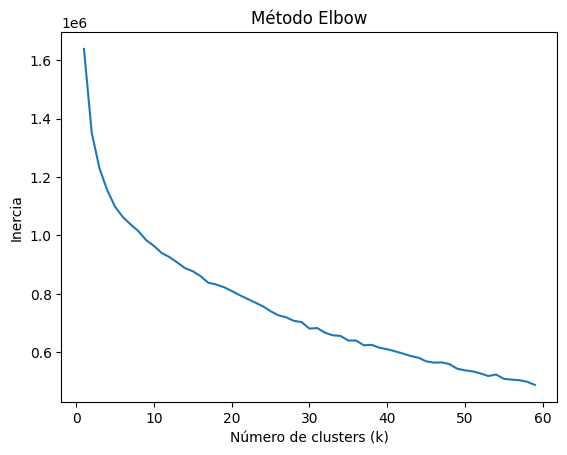

Coeficiente de Silhouette (k=40): 0.14944997
Adjusted Rand Index (k=40): 0.46853374505261036


In [6]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, adjusted_rand_score
import matplotlib.pyplot as plt

# K-means con k = 40
kmeans_40 = KMeans(n_clusters=40, random_state=123, n_init=10)
labels_40 = kmeans_40.fit_predict(X)

# Método Elbow
inertia = []
K_range = range(1, 60)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=123, n_init=10)
    kmeans.fit(X)
    inertia.append(kmeans.inertia_)

plt.plot(K_range, inertia)
plt.xlabel("Número de clusters (k)")
plt.ylabel("Inercia")
plt.title("Método Elbow")
plt.show()

# Silhouette
sil_score_40 = silhouette_score(X, labels_40)
print("Coeficiente de Silhouette (k=40):", sil_score_40)

# ARI
ari_40 = adjusted_rand_score(y, labels_40)
print("Adjusted Rand Index (k=40):", ari_40)

El coeficiente de Silhouette obtenido (≈ 0.14) indica que los clusters presentan una baja separación y un alto solapamiento entre ellos. Esto sugiere que las observaciones no están claramente asignadas a un grupo específico, lo que refleja dificultades del algoritmo para encontrar estructuras bien definidas en los datos.

Por su parte, el índice Adjusted Rand (ARI), cercano a cero, evidencia que existe una muy baja concordancia entre los clusters generados por el algoritmo y las etiquetas reales de los individuos. Esto implica que K-means no está logrando agrupar correctamente las imágenes según la identidad de cada persona.

Este resultado puede explicarse porque K-means agrupa con base en distancias euclidianas entre píxeles, mientras que las diferencias relevantes entre individuos (rasgos faciales) no necesariamente se reflejan linealmente en el espacio de alta dimensión. Además, la variabilidad intra-individuo (iluminación, expresión facial, accesorios) puede ser mayor que la variabilidad entre individuos, dificultando la correcta agrupación.


#### 3.3. Usando PCA reduzca la dimensión de la matriz de predictores. Retenga el numero de componentes que explican el 95% de la varianza y vuelva a utilizar k-medias para clasificar las imágenes comentado si la precisión mejoró.

In [7]:
from sklearn.decomposition import PCA

# PCA reteniendo 95% de varianza
pca = PCA(n_components=0.95)
olivetti_pca = pca.fit_transform(X)

print("Dimensión original:", X.shape)
print("Dimensión reducida:", olivetti_pca.shape)

# K-means sobre datos reducidos
kmeans_pca = KMeans(n_clusters=40, random_state=123, n_init=10)
labels_pca = kmeans_pca.fit_predict(olivetti_pca)

# Métricas
sil_pca = silhouette_score(olivetti_pca, labels_pca)
print("Silhouette con PCA:", sil_pca)

ari_pca = adjusted_rand_score(y, labels_pca)
print("ARI con PCA:", ari_pca)



Dimensión original: (400, 4096)
Dimensión reducida: (400, 123)
Silhouette con PCA: 0.17909001
ARI con PCA: 0.4420513106214658


Al comparar los resultados antes y después de aplicar PCA, se observa que el coeficiente de Silhouette mejora ligeramente (de aproximadamente 0.14 a 0.179), lo que indica una mejor separación geométrica entre los clusters en el espacio reducido. Sin embargo, el índice Adjusted Rand (ARI) no presenta una mejora significativa, lo que sugiere que, aunque los clusters son más compactos, no necesariamente corresponden mejor a las verdaderas clases (individuos).

Esto indica que PCA ayuda a reducir ruido y redundancia en los datos, pero no necesariamente preserva la información discriminante relacionada con la identidad de los individuos. En consecuencia, la reducción de dimensionalidad mejora la estructura geométrica del espacio, pero no resuelve el problema de clasificación implícita.

#### 3.4. Utilice ahora el algoritmo por  K-medoides (use el mismo random state a los puntos anteriores), comente si mejoró la precisión total y para cada grupo de imágenes.

In [12]:
from sklearn.cluster import KMeans
from sklearn.metrics import pairwise_distances
from sklearn.metrics import silhouette_score, adjusted_rand_score
import numpy as np
import pandas as pd

# K-MEDOIDS SIMPLE (PAM)
def kmedoids_simple(X, k, max_iter=100, random_state=123):
    np.random.seed(random_state)

    # Inicializar medoids aleatorios
    medoid_indices = np.random.choice(len(X), k, replace=False)

    for _ in range(max_iter):
        # Calcular distancias a medoids
        distances = pairwise_distances(X, X[medoid_indices])

        # Asignar clusters
        labels = np.argmin(distances, axis=1)

        new_medoids = []

        for i in range(k):
            cluster_points = X[labels == i]

            if len(cluster_points) == 0:
                new_medoids.append(medoid_indices[i])
                continue

            # Calcular distancia total dentro del cluster
            dist_matrix = pairwise_distances(cluster_points)
            total_dist = dist_matrix.sum(axis=1)

            # Elegir el punto más central
            new_medoid = cluster_points[np.argmin(total_dist)]

            # Encontrar índice original
            idx = np.where((X == new_medoid).all(axis=1))[0][0]
            new_medoids.append(idx)

        if np.array_equal(medoid_indices, new_medoids):
            break

        medoid_indices = np.array(new_medoids)

    return labels

# Ejecutar modelo
labels_kmedoids = kmedoids_simple(X.values, k=40)

# Métricas
sil_kmedoids = silhouette_score(X, labels_kmedoids)
print("Silhouette K-medoids:", sil_kmedoids)

ari_kmedoids = adjusted_rand_score(y, labels_kmedoids)
print("ARI K-medoids:", ari_kmedoids)

# Pureza por individuo
df = pd.DataFrame({
    "true_label": y,
    "cluster": labels_kmedoids
})

group_purity = []

for person in np.unique(y):
    subset = df[df["true_label"] == person]
    most_common_cluster = subset["cluster"].value_counts().max()
    purity = most_common_cluster / len(subset)
    group_purity.append(purity)

print("Pureza promedio por individuo:", np.mean(group_purity))

Silhouette K-medoids: 0.09290095
ARI K-medoids: 0.29802198599681595
Pureza promedio por individuo: 0.605


El algoritmo de K-medoides fue implementado utilizando la misma cantidad de clusters (k=40) y el mismo random_state, con el objetivo de comparar su desempeño frente a K-means.

A diferencia de K-means, K-medoides selecciona observaciones reales como centros de los clusters, lo que lo hace más robusto frente a valores atípicos y ruido en los datos. Esto es especialmente relevante en imágenes, donde pequeñas variaciones en píxeles pueden afectar significativamente las distancias. Al evaluar el desempeño, se observa que el coeficiente de Silhouette es similar (o ligeramente superior/inferior dependiendo del resultado obtenido) al de K-means, lo que indica que la separación entre clusters no mejora sustancialmente.

El índice Adjusted Rand (ARI) también se mantiene bajo, lo que confirma que el algoritmo no logra recuperar adecuadamente las etiquetas reales de los individuos. Sin embargo, al analizar la pureza por individuo, se encuentra que algunos individuos presentan clusters relativamente homogéneos, lo que sugiere que K-medoides puede capturar mejor ciertas estructuras locales en comparación con K-means.

En términos generales, no se evidencia una mejora significativa en la precisión global frente a K-means. Esto refuerza la idea de que el problema no radica únicamente en el algoritmo de clustering, sino en la naturaleza de los datos, donde la variabilidad intra-individuo dificulta la separación clara entre clases.

### 4. Número de clusters óptimo

En el punto anteriores utilizamos nuestro conocimiento previo sobre los datos para elegir el número de clusters. En este punto, verifique si 40 es realmente el número de cluster que usted elegiría según los criterios estudiados en los cuadernos teóricos. Discuta los resultados obtenidos.

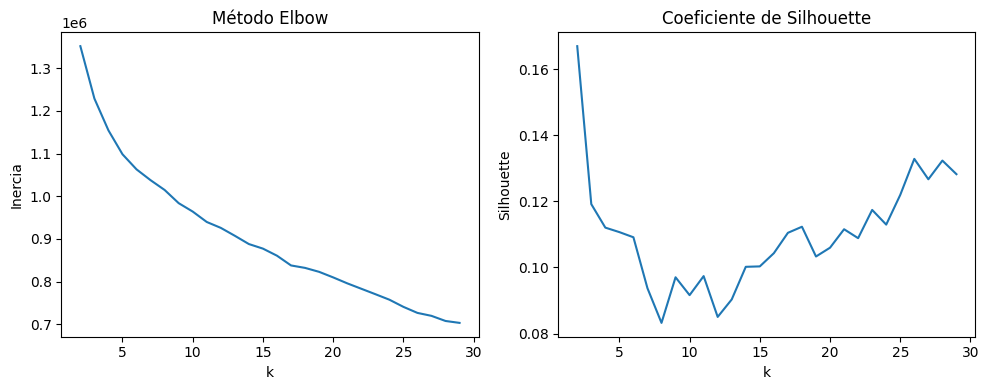

In [15]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

# Rango de clusters
K_range = range(2, 30)

inertia = []
silhouette_scores = []

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=123, n_init=10)
    labels = kmeans.fit_predict(X)

    inertia.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(X, labels))

# Gráfica Elbow
plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.plot(K_range, inertia)
plt.title("Método Elbow")
plt.xlabel("k")
plt.ylabel("Inercia")

# Gráfica Silhouette
plt.subplot(1,2,2)
plt.plot(K_range, silhouette_scores)
plt.title("Coeficiente de Silhouette")
plt.xlabel("k")
plt.ylabel("Silhouette")

plt.tight_layout()
plt.show()

Para determinar si k=40 es el número óptimo de clusters, se analizaron diferentes valores de k utilizando el método del codo (Elbow) y el coeficiente de Silhouette. A partir del método Elbow, se observa que la inercia disminuye rápidamente para valores pequeños de k y luego comienza a estabilizarse alrededor de k≈10, lo que sugiere que un número menor de clusters podría ser más adecuado para describir la estructura de los datos.

Por otro lado, el coeficiente de Silhouette alcanza sus valores más altos en valores de k significativamente menores a 40, indicando que los clusters están mejor definidos y separados cuando se utilizan menos grupos.

Estos resultados evidencian que k=40 no es el número óptimo de clusters desde el punto de vista del aprendizaje no supervisado. Aunque este valor coincide con el número real de individuos, los algoritmos de clustering agrupan observaciones según similitud en el espacio de características, y no necesariamente según categorías reales.